In [5]:
#Tratamiento de datos
import numpy as np
import pandas as pd

#Gráficos
import matplotlib.pyplot as plt

#Preprocesado y modelado
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA


In [7]:
# Datos del iris.csv organizados en un arreglo numpy

df_completo = pd.DataFrame(np.array([
    [5.1, 3.5, 1.4, 0.2, "Setosa"],
    [4.9, 3.0, 1.4, 0.2, "Setosa"],
    [4.7, 3.2, 1.3, 0.2, "Setosa"],
    [4.6, 3.1, 1.5, 0.2, "Setosa"],
    [5.0, 3.6, 1.4, 0.2, "Setosa"],
    [5.4, 3.9, 1.7, 0.4, "Setosa"],
    [4.6, 3.4, 1.4, 0.3, "Setosa"],
    [5.0, 3.4, 1.5, 0.2, "Setosa"],
    [4.4, 2.9, 1.4, 0.2, "Setosa"],
    [4.9, 3.1, 1.5, 0.1, "Setosa"],
    [5.4, 3.7, 1.5, 0.2, "Setosa"],
    [4.8, 3.4, 1.6, 0.2, "Setosa"],
    [4.8, 3.0, 1.4, 0.1, "Setosa"],
    [4.3, 3.0, 1.1, 0.1, "Setosa"],
    [5.8, 4.0, 1.2, 0.2, "Setosa"],
    [5.7, 4.4, 1.5, 0.4, "Setosa"],
    [5.4, 3.9, 1.3, 0.4, "Setosa"],
    [5.1, 3.5, 1.4, 0.3, "Setosa"],
    [5.7, 3.8, 1.7, 0.3, "Setosa"],
    [5.1, 3.8, 1.5, 0.3, "Setosa"],
    [5.4, 3.4, 1.7, 0.2, "Setosa"],
    [5.1, 3.7, 1.5, 0.4, "Setosa"],
    [4.6, 3.6, 1.0, 0.2, "Setosa"],
    [5.1, 3.3, 1.7, 0.5, "Setosa"],
    [4.8, 3.4, 1.9, 0.2, "Setosa"],
    [5.0, 3.0, 1.6, 0.2, "Setosa"],
    [5.0, 3.4, 1.6, 0.4, "Setosa"],
    [5.2, 3.5, 1.5, 0.2, "Setosa"],
    [5.2, 3.4, 1.4, 0.2, "Setosa"],
    [4.7, 3.2, 1.6, 0.2, "Setosa"],
    [4.8, 3.1, 1.6, 0.2, "Setosa"],
    [5.4, 3.4, 1.5, 0.4, "Setosa"],
    [5.2, 4.1, 1.5, 0.1, "Setosa"],
    [5.5, 4.2, 1.4, 0.2, "Setosa"],
    [4.9, 3.1, 1.5, 0.2, "Setosa"],
    [5.0, 3.2, 1.2, 0.2, "Setosa"],
    [5.5, 3.5, 1.3, 0.2, "Setosa"],
    [4.9, 3.6, 1.4, 0.1, "Setosa"],
    [4.4, 3.0, 1.3, 0.2, "Setosa"],
    [5.1, 3.4, 1.5, 0.2, "Setosa"],
    [5.0, 3.5, 1.3, 0.3, "Setosa"],
    [4.5, 2.3, 1.3, 0.3, "Setosa"],
    [4.4, 3.2, 1.3, 0.2, "Setosa"],
    [5.0, 3.5, 1.6, 0.6, "Setosa"],
    [5.1, 3.8, 1.9, 0.4, "Setosa"],
    [4.8, 3.0, 1.4, 0.3, "Setosa"],
    [5.1, 3.8, 1.6, 0.2, "Setosa"],
    [4.6, 3.2, 1.4, 0.2, "Setosa"],
    [5.3, 3.7, 1.5, 0.2, "Setosa"],
    [5.0, 3.3, 1.4, 0.2, "Setosa"],
    [7.0, 3.2, 4.7, 1.4, "Versicolor"],
    [6.4, 3.2, 4.5, 1.5, "Versicolor"],
    [6.9, 3.1, 4.9, 1.5, "Versicolor"],
    [5.5, 2.3, 4.0, 1.3, "Versicolor"],
    [6.5, 2.8, 4.6, 1.5, "Versicolor"],
    [5.7, 2.8, 4.5, 1.3, "Versicolor"],
    [6.3, 3.3, 4.7, 1.6, "Versicolor"],
    [4.9, 2.4, 3.3, 1.0, "Versicolor"],
    [6.6, 2.9, 4.6, 1.3, "Versicolor"],
    [5.2, 2.7, 3.9, 1.4, "Versicolor"],
    [5.0, 2.0, 3.5, 1.0, "Versicolor"],
    [5.9, 3.0, 4.2, 1.5, "Versicolor"],
    [6.0, 2.2, 4.0, 1.0, "Versicolor"],
    [6.1, 2.9, 4.7, 1.4, "Versicolor"],
    [5.6, 2.9, 3.6, 1.3, "Versicolor"],
    [6.7, 3.1, 4.4, 1.4, "Versicolor"],
    [5.6, 3.0, 4.5, 1.5, "Versicolor"],
    [5.8, 2.7, 4.1, 1.0, "Versicolor"],
    [6.2, 2.2, 4.5, 1.5, "Versicolor"],
    [5.6, 2.5, 3.9, 1.1, "Versicolor"],
    [5.9, 3.2, 4.8, 1.8, "Versicolor"],
    [6.1, 2.8, 4.0, 1.3, "Versicolor"],
    [6.3, 2.5, 4.9, 1.5, "Versicolor"],
    [6.1, 2.8, 4.7, 1.2, "Versicolor"],
    [6.4, 2.9, 4.3, 1.3, "Versicolor"],
    [6.6, 3.0, 4.4, 1.4, "Versicolor"],
    [6.8, 2.8, 4.8, 1.4, "Versicolor"],
    [6.7, 3.0, 5.0, 1.7, "Versicolor"],
    [6.0, 2.9, 4.5, 1.5, "Versicolor"],
    [5.7, 2.6, 3.5, 1.0, "Versicolor"],
    [5.5, 2.4, 3.8, 1.1, "Versicolor"],
    [5.5, 2.4, 3.7, 1.0, "Versicolor"],
    [5.8, 2.7, 3.9, 1.2, "Versicolor"],
    [6.0, 2.7, 5.1, 1.6, "Versicolor"],
    [5.4, 3.0, 4.5, 1.5, "Versicolor"],
    [6.0, 3.4, 4.5, 1.6, "Versicolor"],
    [6.7, 3.1, 4.7, 1.5, "Versicolor"],
    [6.3, 2.3, 4.4, 1.3, "Versicolor"],
    [5.6, 3.0, 4.1, 1.3, "Versicolor"],
    [5.5, 2.5, 4.0, 1.3, "Versicolor"],
    [5.5, 2.6, 4.4, 1.2, "Versicolor"],
    [6.1, 3.0, 4.6, 1.4, "Versicolor"],
    [5.8, 2.6, 4.0, 1.2, "Versicolor"],
    [5.0, 2.3, 3.3, 1.0, "Versicolor"],
    [5.6, 2.7, 4.2, 1.3, "Versicolor"],
    [5.7, 3.0, 4.2, 1.2, "Versicolor"],
    [5.7, 2.9, 4.2, 1.3, "Versicolor"],
    [6.2, 2.9, 4.3, 1.3, "Versicolor"],
    [5.1, 2.5, 3.0, 1.1, "Versicolor"],
    [5.7, 2.8, 4.1, 1.3, "Versicolor"],
    [6.3, 3.3, 6.0, 2.5, "Virginica"],
    [5.8, 2.7, 5.1, 1.9, "Virginica"],
    [7.1, 3.0, 5.9, 2.1, "Virginica"],
    [6.3, 2.9, 5.6, 1.8, "Virginica"],
    [6.5, 3.0, 5.8, 2.2, "Virginica"],
    [7.6, 3.0, 6.6, 2.1, "Virginica"],
    [4.9, 2.5, 4.5, 1.7, "Virginica"],
    [7.3, 2.9, 6.3, 1.8, "Virginica"],
    [6.7, 2.5, 5.8, 1.8, "Virginica"],
    [7.2, 3.6, 6.1, 2.5, "Virginica"],
    [6.5, 3.2, 5.1, 2.0, "Virginica"],
    [6.4, 2.7, 5.3, 1.9, "Virginica"],
    [6.8, 3.0, 5.5, 2.1, "Virginica"],
    [5.7, 2.5, 5.0, 2.0, "Virginica"],
    [5.8, 2.8, 5.1, 2.4, "Virginica"],
    [6.4, 3.2, 5.3, 2.3, "Virginica"],
    [6.5, 3.0, 5.5, 1.8, "Virginica"],
    [7.7, 3.8, 6.7, 2.2, "Virginica"],
    [7.7, 2.6, 6.9, 2.3, "Virginica"],
    [6.0, 2.2, 5.0, 1.5, "Virginica"],
    [6.9, 3.2, 5.7, 2.3, "Virginica"],
    [5.6, 2.8, 4.9, 2.0, "Virginica"],
    [7.7, 2.8, 6.7, 2.0, "Virginica"],
    [6.3, 2.7, 4.9, 1.8, "Virginica"],
    [6.7, 3.3, 5.7, 2.1, "Virginica"],
    [7.2, 3.2, 6.0, 1.8, "Virginica"],
    [6.2, 2.8, 4.8, 1.8, "Virginica"],
    [6.1, 3.0, 4.9, 1.8, "Virginica"],
    [6.4, 2.8, 5.6, 2.1, "Virginica"],
    [7.2, 3.0, 5.8, 1.6, "Virginica"],
    [7.4, 2.8, 6.1, 1.9, "Virginica"],
    [7.9, 3.8, 6.4, 2.0, "Virginica"],
    [6.4, 2.8, 5.6, 2.2, "Virginica"],
    [6.3, 2.8, 5.1, 1.5, "Virginica"],
    [6.1, 2.6, 5.6, 1.4, "Virginica"],
    [7.7, 3.0, 6.1, 2.3, "Virginica"],
    [6.3, 3.4, 5.6, 2.4, "Virginica"],
    [6.4, 3.1, 5.5, 1.8, "Virginica"],
    [6.0, 3.0, 4.8, 1.8, "Virginica"],
    [6.9, 3.1, 5.4, 2.1, "Virginica"],
    [6.7, 3.1, 5.6, 2.4, "Virginica"],
    [6.9, 3.1, 5.1, 2.3, "Virginica"],
    [5.8, 2.7, 5.1, 1.9, "Virginica"],
    [6.8, 3.2, 5.9, 2.3, "Virginica"],
    [6.7, 3.3, 5.7, 2.5, "Virginica"],
    [6.7, 3.0, 5.2, 2.3, "Virginica"],
    [6.3, 2.5, 5.0, 1.9, "Virginica"],
    [6.5, 3.0, 5.2, 2.0, "Virginica"],
    [6.2, 3.4, 5.4, 2.3, "Virginica"],
    [5.9, 3.0, 5.1, 1.8, "Virginica"]
]),
index = range(1, 151),  # Índices del 1 al 150
columns = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width', 'variety'])

# Guardamos la columna categórica en una variable aparte
variety = df_completo['variety']

# df se queda solo con las columnas numéricas (la quitamos con drop)
df = df_completo.drop(columns=['variety'])

df

,sepal.length,sepal.width,petal.length,petal.width
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2
...,...,...,...,...
146,6.7,3.0,5.2,2.3
147,6.3,2.5,5.0,1.9
148,6.5,3.0,5.2,2.0
149,6.2,3.4,5.4,2.3


In [8]:
#Determinar el numero de renglones de la base de datos
index = df.index
renglones = len(index)
renglones

150

In [9]:
#Estandarización de las variables
df2 = StandardScaler().fit_transform(df)
df2

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [10]:
#Calculo de la matriz de correlaciones para la matriz transformada
A = (1/ renglones) * np.dot(df2.T,df2)
A

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [11]:
#Entrenamiento del modelo PCA con escalado de los datos
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(df)

#Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']
print("Eigenvalores:")
results = LA.eigvals(A)
print(results)

Eigenvalores:
[2.91849782 0.91403047 0.14675688 0.02071484]


In [12]:
# Porcentaje de la varianza explicada por cada nuevo componente
print("Porcentaje de varianza explicada por componente")
print(modelo_pca.explained_variance_ratio_)

#RESPUESTA DEL PASO 2 DE LA ACTIVIDAD
print("Grado de explicación de la varianza al utilizar los dos primeros componentes:")
#(Suma los dos primeros componentes)
print(((modelo_pca.explained_variance_ratio_[0]+modelo_pca.explained_variance_ratio_[1])*100))

Porcentaje de varianza explicada por componente
[0.72962445 0.22850762 0.03668922 0.00517871]
Grado de explicación de la varianza al utilizar los dos primeros componentes:
95.81320720000164


Eigenvectores (por renglón):


,sepal.length,sepal.width,petal.length,petal.width
PC1,0.521066,-0.269347,0.580413,0.564857
PC2,0.377418,0.923296,0.024492,0.066942
PC3,-0.719566,0.244382,0.142126,0.634273
PC4,-0.261286,0.123510,0.801449,-0.523597


In [13]:
#Proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, df2.T)
proyecciones = pd.DataFrame(proyecciones, index = ['PC1', 'PC2', 'PC3','PC4'])
proyecciones = proyecciones.transpose().set_index(df.index)
proyecciones['variety'] = variety.values   # <-- Volvemos a agregar la variable no numérica
proyecciones

,PC1,PC2,PC3,PC4,variety
1,-2.264703,0.480027,-0.127706,-0.024168,Setosa
2,-2.080961,-0.674134,-0.234609,-0.103007,Setosa
3,-2.364229,-0.341908,0.044201,-0.028377,Setosa
4,-2.299384,-0.597395,0.091290,0.065956,Setosa
5,-2.389842,0.646835,0.015738,0.035923,Setosa
...,...,...,...,...,...
146,1.870503,0.386966,0.256274,-0.389257,Virginica
147,1.564580,-0.896687,-0.026371,-0.220192,Virginica
148,1.521170,0.269069,0.180178,-0.119171,Virginica
149,1.372788,1.011254,0.933395,-0.026129,Virginica


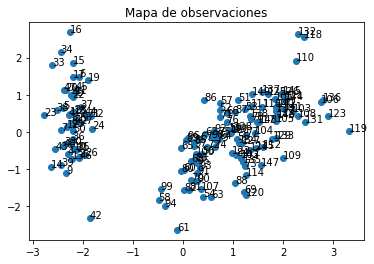

In [14]:
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]
z = df.index
x = x.to_numpy()
y = y.to_numpy()
fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

Se observan dos clusters principales, donde el cluster 1 se compone de todas las setosas excepto la 42 y el segundo cluster incluye a las variedades de versicolor, virginica y la obs 42 que pertenece al grupo de las setosas.


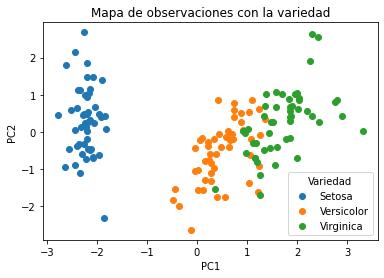

In [15]:
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]
especies = proyecciones['variety']

x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones con la variedad")

for especie in especies.unique():
    mask = (especies == especie).to_numpy()
    ax.scatter(x[mask], y[mask], label=especie)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Variedad")

#RESPUESTA DEL PASO 3 DE LA ACTIVIDAD
print("Se observan dos clusters principales, donde el cluster 1 se compone de todas las setosas excepto la 42 y el segundo cluster incluye a las variedades de versicolor, virginica y la obs 42 que pertenece al grupo de las setosas.")

In [16]:
componentes_2 = pd.DataFrame(data= modelo_pca.components_,
                             columns = df.columns,
                             index = ['PC1', 'PC2', 'PC3','PC4'])
componentes_2 = componentes_2.iloc[0:2,:]
componentes_2 = componentes_2.T
componentes_2 

,PC1,PC2
sepal.length,0.521066,0.377418
sepal.width,-0.269347,0.923296
petal.length,0.580413,0.024492
petal.width,0.564857,0.066942


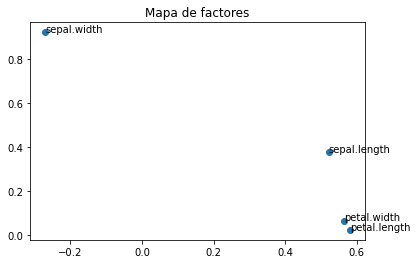

In [18]:
x = componentes_2.iloc[:,0]
y = componentes_2.iloc[:,1]
z = componentes_2.index
x = x.to_numpy()
y = y.to_numpy()
fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x,y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

In [19]:
#Procedimiento para obtener la matriz estandarizada original
proyecciones_num = proyecciones.drop(columns=['variety'])  # quitamos la columna de texto
original = np.dot(modelo_pca.components_.T, proyecciones_num.T)
original = original.T
print(original)

[[-9.00681170e-01  1.01900435e+00 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00 -1.31979479e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.38535265e+00  3.28414053e-01 -1.39706395e+00 -1.31544430e+00]
 [-1.50652052e+00  9.82172869e-02 -1.28338910e+00 -1.31544430e+00]
 [-1.02184904e+00  1.24920112e+00 -1.34022653e+00 -1.31544430e+00]
 [-5.37177559e-01  1.93979142e+00 -1.16971425e+00 -1.05217993e+00]
 [-1.50652052e+00  7.88807586e-01 -1.34022653e+00 -1.18381211e+00]
 [-1.02184904e+00  7.88807586e-01 -1.28338910e+00 -1.31544430e+00]
 [-1.74885626e+00 -3.62176246e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00  9.82172869e-02 -1.28338910e+00 -1.44707648e+00]
 [-5.37177559e-01  1.47939788e+00 -1.28338910e+00 -1.31544430e+00]
 [-1.26418478e+00  7.88807586e-01 -1.22655167e+00 -1.31544430e+00]
 [-1.26418478e+00 -1.31979479e-01 -1.34022653e+00 -1.44707648e+00]
 [-1.87002413e+00 -1.31979479e-01 -1.51073881e+00 -1.44707648e+00]
 [-5.25060772e-02  2.16998818e+00 -1.45390138e+00 -1.31544430e

In [24]:
#RESPUESTA DEL PASO 3 DE LA ACTIVIDAD: CASOS ESPECIFICOS

#Las obs elegidas fueron tomadas del mapa de observaciones de cada cluster

#Se espera que sea Setosa
Obs_Cluster1 = df_completo.iloc[14]

#Se espera que sea Versicolor o Virginica    
Obs_Cluster2 = df_completo.iloc[118]

print(Obs_Cluster1)
print(Obs_Cluster2)


#RESPUESTA 
print(".")

sepal.length       5.8
sepal.width        4.0
petal.length       1.2
petal.width        0.2
variety         Setosa
Name: 15, dtype: object
sepal.length          7.7
sepal.width           2.6
petal.length          6.9
petal.width           2.3
variety         Virginica
Name: 119, dtype: object
Se observan dos clusters principales, donde el cluster 1 se compone de todas las setosas excepto la 42 y el segundo cluster incluye a las variedades de versicolor, virginica y la obs 42 que pertenece al grupo de las setosas.
